In [16]:
import pandas as pd
import numpy as np

csv_path = "https://www.statlearning.com/s/Advertising.csv"

In [17]:
data_df = pd.read_csv(csv_path, index_col=0)
data_df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [18]:
X = data_df[["TV","radio"]].to_numpy()
Y = data_df[["sales"]].to_numpy()

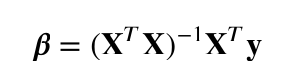

In [19]:
X = np.concat(
    ( np.ones((X.shape[0], 1)) , X ),
    axis=1
)

In [21]:
first_term = np.linalg.inv(np.dot(X.T,X))
betas = first_term.dot(X.T).dot(Y)

In [25]:
betas = betas.flatten()

In [26]:
print(f"y = {betas[0]:.3f} + {betas[1]:.3f} x1 + {betas[2]:.3f} x2")

y = 2.921 + 0.046 x1 + 0.188 x2


### Sklearn Implementaion

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SSE = lambda y_true, y_pred : np.sum(np.power((y_true - y_pred), 2))

In [59]:
X = data_df[["TV","radio","newspaper"]].to_numpy()
Y = data_df[["sales"]].to_numpy()

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=999)

In [62]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
lin_reg.intercept_ , lin_reg.coef_

(array([14.04698079]), array([[ 3.89975309,  2.70029866, -0.09318076]]))

In [64]:
y_pred = lin_reg.predict(X_test)

In [66]:
print("SSE = ", SSE(y_test, y_pred))
print("MSE = ", mean_squared_error(y_test, y_pred))
print("MAE = ", mean_absolute_error(y_test, y_pred))
print("R2 coeff = ", r2_score(y_test, y_pred))

SSE =  108.53842086468956
MSE =  2.7134605216172387
MAE =  1.2836073886699872
R2 coeff =  0.8928645182685834


##  Adjusted R2 coeff

## The Core Problem

R² has a major weakness:

> It almost never decreases when new predictors are added.

Even completely useless variables can slightly increase R².

This creates a misleading impression that the model is improving.


### Why Does R² Increase?

Recall:

$R^2 = 1 - \frac{RSS}{TSS}$

Where:

* (RSS) = unexplained error
* (TSS) = total variation

When a new variable is added:

* The regression model gains extra flexibility.
* It can fit the training data more closely.
* Therefore residual error ((RSS)) usually decreases.

Since:

$R^2 = 1 - \frac{smaller\ number}{same\ number}$

R² increases.


### Why is This Dangerous?

Suppose we are predicting salary.

### Useful Features

* Years of experience
* Education level
* Skill score

Model:

* R² = 0.81


Now add:

### Random Features

* Favorite movie
* Shoe size
* Lucky number

New Model:

* R² = 0.814

The increase happens because:

* The model memorizes small random patterns.
* More variables make the model more flexible.
* Training fit improves slightly.

But:

* Real predictive power may not improve.
* Future prediction may become worse.
* Model becomes unnecessarily complex.

This problem is called:

#### Overfitting


### The Main Idea Behind Adjusted R²

Adjusted R² asks an important question:

> "Did the new variable improve the model enough to justify its complexity?"

Instead of blindly rewarding additional variables, it introduces a penalty.

Regular R² only rewards:

* Better fit

Adjusted R² balances two things:

| Goal            | Effect  |
| --------------- | ------- |
| Better fit      | Reward  |
| More predictors | Penalty |

So:

* Useful variables → Adjusted R² increases
* Useless variables → Adjusted R² decreases


Adjusted R² modifies R² by penalizing unnecessary predictors.

It increases only if:

> The new variable improves the model more than expected by chance.


## Formula

$Adjusted\ R^2 = 1 - (1 - R^2)\frac{n-1}{n-d-1} $

Where:

| Symbol | Meaning                |
| ------ | ---------------------- |
| (R^2)  | Regular R²             |
| (n)    | Number of observations (rows) |
| (d)    | Number of predictors (columns)   |


### Core Idea

Adjusted R² introduces a penalty factor:

$\frac{n-1}{n-p-1}$

As the number of predictors (p) increases:

* Denominator becomes smaller
* Penalty becomes larger

Therefore:

* Irrelevant variables may reduce Adjusted R².
* Useful variables increase Adjusted R².

### Can Adjusted R² Be Negative?

Yes.

This happens when:

* The model performs very poorly.
* Predictors explain almost nothing.

A negative Adjusted R² means:

> The model is worse than simply predicting the mean.


In [68]:
from sklearn.metrics import r2_score

def adj_r2(y_true, y_pred, d= 3):
    r2score = r2_score(y_true, y_pred)
    
    n = len(y_true)
    
    return 1 - (1- r2score) * ((n-1) / (n-d-1))

In [71]:
print("Adjusted R2 Score : " , adj_r2(y_test, y_pred, d= X_test.shape[-1]))

Adjusted R2 Score :  0.883936561457632


In [70]:
print("R2 coeff = ", r2_score(y_test, y_pred))

R2 coeff =  0.8928645182685834


## Plot 3D

<Figure size 1000x700 with 0 Axes>

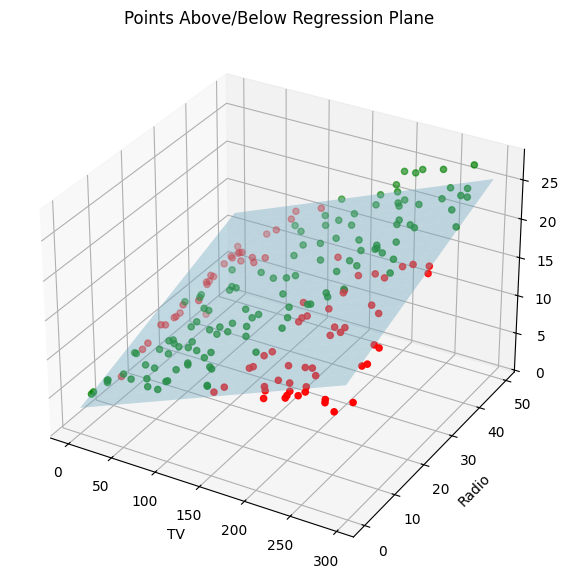

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Example data
TV = X[:,0]
radio = X[:,1]
Sales = Y.flatten()

# Example predicted values
y_pred = lin_reg.predict(X).flatten()

# Create figure
fig = plt.figure(figsize=(10, 7))

# Example regression coefficients
# Sales = b0 + b1*TV + b2*radio
b0 = lin_reg.intercept_[0]
b1, b2 = lin_reg.coef_[0]

# Assign colors
colors = np.where(Sales > y_pred, 'green', 'red')

# Create figure
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with conditional colors
ax.scatter(
    TV,
    radio,
    Sales,
    c=colors,
    s=20
)

# Create plane mesh
tv_grid, radio_grid = np.meshgrid(
    np.linspace(TV.min(), TV.max(), 20),
    np.linspace(radio.min(), radio.max(), 20)
)

# Plane equation
sales_plane = b0 + b1 * tv_grid + b2 * radio_grid

# Plot regression plane
ax.plot_surface(
    tv_grid,
    radio_grid,
    sales_plane,
    alpha=0.4,
    color='skyblue'
)

# Labels
ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Sales")

ax.set_title("Points Above/Below Regression Plane")

plt.show()